# NashDQN on VMAS Simple Tag

Trains and evaluates **NashDQN** on the **Multi-Particle Simple Tag** environment using [BenchMARL](https://github.com/facebookresearch/BenchMARL) for the training harness and [VMAS](https://github.com/proroklab/VectorizedMultiAgentSimulator) for vectorised simulation.

## Scenario
| Parameter | Value |
|---|---|
| Good agents (prey) | 1 |
| Adversaries (predators) | 3 |
| Obstacles | 2 |

All **4 agents** (1 prey + 3 predators) use the **same algorithm**.

## Switching algorithms
Change `ALGORITHM` in the *Config* cell:
- `"nash_dqn"` — Independent Q-Learning with a target network (NashDQN baseline)
- `"sre_dqn"` — SRE-DQN (register a custom BenchMARL algorithm and uncomment the branch in `build_algorithm_config`)


In [1]:
from pathlib import Path
import sys

import torch

from benchmarl.experiment import Experiment
from benchmarl.models import MlpConfig

BASE_DIR = Path.cwd().resolve()

from simple_tag_nash_adapter import NashDqnConfig
from simple_tag_notebook_utils import (
    build_off_policy_experiment_config,
    collect_eval_rollouts,
    configure_simple_tag_task,
    find_latest_checkpoint,
    make_run_root,
    plot_reward_metrics_for_run,
    print_run_settings,
    render_latest_policy_video,
    save_simple_tag_eval_diagnostics,
    summarize_simple_tag_rollouts,
)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
print("Base dir:", BASE_DIR)


Using device: cuda:0
Base dir: /home/wowthecoder/SRE-DQN/continous_action_space


In [2]:
# Shared Simple Tag environment and training settings
N_GOOD_AGENTS = 1
N_ADVERSARIES = 3
N_OBSTACLES = 2
MAX_STEPS = 100
CONTINUOUS_ACTIONS = True

SEED = 0
NUM_ENVS = 64
FRAMES_PER_BATCH = NUM_ENVS * MAX_STEPS
TRAIN_BATCH_SIZE = 512
REPLAY_BUFFER_SIZE = 100_000
EVAL_EVERY_ITERS = 20
CKPT_EVERY_ITERS = 25

print("Shared Simple Tag settings loaded.")
print(f"  Scenario: {N_GOOD_AGENTS} prey + {N_ADVERSARIES} predators + {N_OBSTACLES} obstacles")
print(f"  MAX_STEPS={MAX_STEPS}")
print(f"  NUM_ENVS={NUM_ENVS}")


Shared Simple Tag settings loaded.
  Scenario: 1 prey + 3 predators + 2 obstacles
  MAX_STEPS=100
  NUM_ENVS=64


## Config

All experiment knobs are here. To swap to SRE-DQN later, change `ALGORITHM = "sre_dqn"` and fill in the corresponding branch of `build_algorithm_config`.

In [2]:
# Nash-DQN experiment settings
ALGORITHM = "nash_dqn"

N_ITERS = 200
OPTIMIZER_STEPS = 1
TARGET_UPDATE_FREQ = 5
EVAL_EPISODES = 5

LR = 1e-3
LATENT_DIMS = 64
LAYERS = 4

EVAL_INTERVAL_FRAMES = EVAL_EVERY_ITERS * FRAMES_PER_BATCH
CKPT_INTERVAL_FRAMES = CKPT_EVERY_ITERS * FRAMES_PER_BATCH

RUN_ROOT = make_run_root(BASE_DIR, ALGORITHM)
print_run_settings(
    "Nash-DQN",
    RUN_ROOT,
    {
        "continuous_actions": CONTINUOUS_ACTIONS,
        "scenario": f"{N_GOOD_AGENTS} prey + {N_ADVERSARIES} predators + {N_OBSTACLES} obstacles",
        "n_iters": N_ITERS,
        "optimizer_steps": OPTIMIZER_STEPS,
        "eval_episodes": EVAL_EPISODES,
        "lr": LR,
    },
)


Algorithm          : nash_dqn
Continuous actions : True
Scenario           : 1 prey + 3 predators + 2 obstacles
Run root           : /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn


## Algorithm factory

`build_algorithm_config(name)` returns the right BenchMARL algorithm config.
All other cells are algorithm-agnostic — only this function needs to change when swapping to SRE-DQN.

## Build Nash-DQN experiment

This section is self-contained after running the shared import/config cells above. You can train only Nash-DQN without touching the MADDPG cells.


In [3]:
def build_nash_experiment():
    algorithm_config = NashDqnConfig(
        device=device,
        max_steps=MAX_STEPS,
        lr=LR,
        lat_dims=LATENT_DIMS,
        layers=LAYERS,
    )
    experiment_config = build_off_policy_experiment_config(
        device=device,
        share_policy_params=False,
        continuous_actions=CONTINUOUS_ACTIONS,
        lr=LR,
        max_n_iters=N_ITERS,
        num_envs=NUM_ENVS,
        frames_per_batch=FRAMES_PER_BATCH,
        train_batch_size=TRAIN_BATCH_SIZE,
        optimizer_steps=OPTIMIZER_STEPS,
        replay_buffer_size=REPLAY_BUFFER_SIZE,
        evaluation_interval=EVAL_INTERVAL_FRAMES,
        evaluation_episodes=EVAL_EPISODES,
        project_name=f"vmas_simple_tag_{ALGORITHM}",
        run_root=RUN_ROOT,
        checkpoint_interval=CKPT_INTERVAL_FRAMES,
        soft_target_update=False,
        hard_target_update_frequency=TARGET_UPDATE_FREQ,
    )
    return Experiment(
        task=configure_simple_tag_task(
            MAX_STEPS,
            N_GOOD_AGENTS,
            N_ADVERSARIES,
            N_OBSTACLES,
        ),
        algorithm_config=algorithm_config,
        model_config=MlpConfig.get_from_yaml(),
        seed=SEED,
        config=experiment_config,
    )


experiment = build_nash_experiment()
print("Configured BenchMARL experiment for custom Nash-DQN.")
print("Experiment name:", experiment.name)
print("Run folder:", experiment.folder_name)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/benchmarl/experiment/experiment.py:313: UserWarning: max_n_frames and max_n_iters have both been set. The experiment will terminate after 200 iterations (1280000 frames).
  warnings.warn(


CUDA IS AVAILABLE!
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


Configured BenchMARL experiment for custom Nash-DQN.
Experiment name: nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37
Run folder: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn/nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37


## Train

In [4]:
if "experiment" not in globals() or experiment is None:
    experiment = build_nash_experiment()
    print("Built Nash-DQN experiment on demand.")

experiment.run()
print("Training complete.")
print("Latest run folder:", experiment.folder_name)


  0%|                                                                                           | 0/200 [00:00<?, ?it/s]

2026-03-29 02:20:46,987 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([100000]) shape [END]
2026-03-29 02:20:48,413 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([100000]) shape [END]


mean return = 0.0: 100%|██████████████████████████████████████████████████████████████| 200/200 [39:14<00:00, 11.77s/it]

Training complete.
Latest run folder: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn/nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37


## Results

Plot episodic reward for the prey (`agent`) and predators (`adversary`) groups.

CSV files found: 162


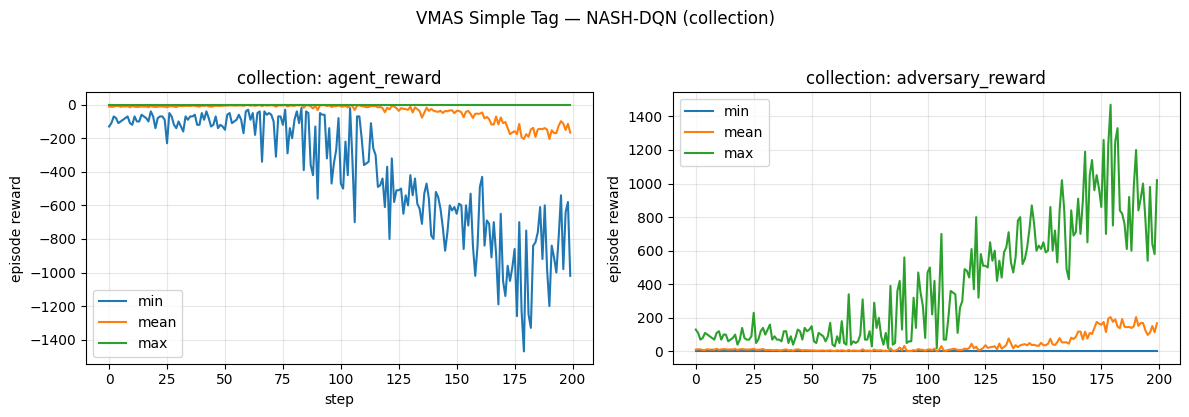

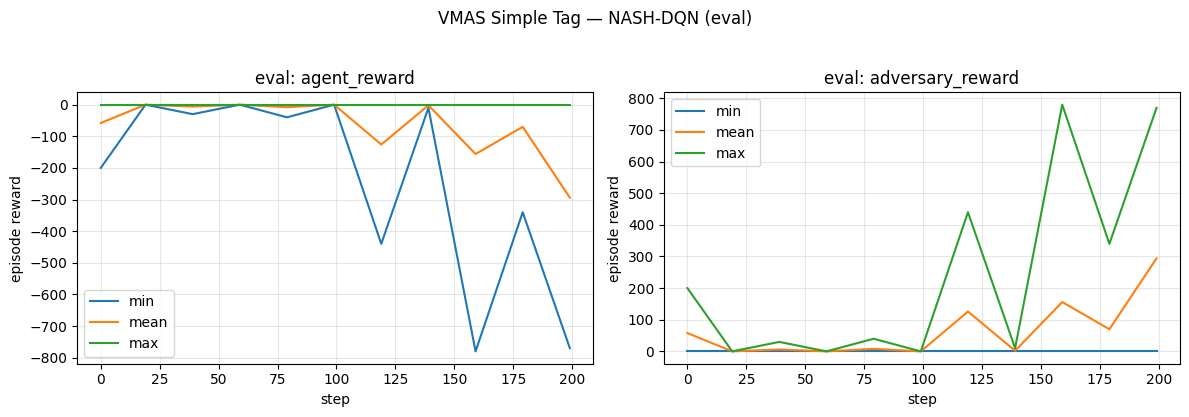

In [5]:
plot_reward_metrics_for_run(RUN_ROOT, ALGORITHM, save=False)


## Evaluate latest checkpoint

In [6]:
latest_ckpt = find_latest_checkpoint(RUN_ROOT)
if latest_ckpt is None:
    print("No checkpoint files found.")
else:
    print("Evaluating checkpoint:", latest_ckpt)
    eval_exp = Experiment.reload_from_file(
        str(latest_ckpt),
        experiment_patch={
            "render": False,
            "evaluation": True,
            "evaluation_episodes": EVAL_EPISODES,
        },
    )
    eval_exp.evaluate()
    print("Evaluation complete.")


Evaluating checkpoint: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn/nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37/checkpoints/checkpoint_1280000.pt
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/benchmarl/experiment/experiment.py:313: UserWarning: max_n_frames and max_n_iters have both been set. The experiment will terminate after 200 iterations (1280000 frames).
  warnings.warn(
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(



Reloaded experiment nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37 from /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn/nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37/checkpoints/checkpoint_1280000.pt.
Evaluation results logged to loggers=['csv'] and to a json file in the experiment folder.
Evaluation complete.


## Render trained policy

In [7]:
render_latest_policy_video(RUN_ROOT, ALGORITHM, max_steps=MAX_STEPS)


CUDA IS AVAILABLE!
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!
CUDA IS AVAILABLE!

Reloaded experiment nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37 from /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn/nashdqn_simple_tag_mlp__d9b21de4_26_03_29-02_20_37/checkpoints/checkpoint_1280000.pt.
Captured 99 frames.
Saved video to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_nash_dqn/manual_videos/nash_dqn_eval.mp4


## Notes

- Run cells `1` and `2` first for shared imports and shared Simple Tag settings.
- Then you can use the Nash-DQN section by itself: `4`, `7`, `9`, `11`, `13`, `15`.
- Or use the MADDPG section by itself: `18`, `20`, `22`, `24`, `26`, `28`.
- The two algorithms now use separate experiment objects and separate run folders.


## MADDPG Baseline

Train a BenchMARL MADDPG baseline on the same VMAS Simple Tag environment, but with MADDPG-specific optimization settings and extra evaluation diagnostics.


In [3]:
from benchmarl.algorithms import MaddpgConfig


MADDPG_ALGORITHM = "maddpg"
MADDPG_RUN_ROOT = make_run_root(BASE_DIR, MADDPG_ALGORITHM)

MADDPG_N_ITERS = 1000
MADDPG_OPTIMIZER_STEPS = 8
MADDPG_EVAL_EPISODES = 20
MADDPG_LR = 3e-4
MADDPG_SHARE_POLICY_PARAMS = True
MADDPG_SHAPE_AGENT_REWARD = True
MADDPG_SHAPE_ADVERSARY_REWARD = True


def build_maddpg_experiment(run_root: Path, project_name: str):
    experiment_config = build_off_policy_experiment_config(
        device=device,
        share_policy_params=MADDPG_SHARE_POLICY_PARAMS,
        continuous_actions=CONTINUOUS_ACTIONS,
        lr=MADDPG_LR,
        max_n_iters=MADDPG_N_ITERS,
        num_envs=NUM_ENVS,
        frames_per_batch=FRAMES_PER_BATCH,
        train_batch_size=TRAIN_BATCH_SIZE,
        optimizer_steps=MADDPG_OPTIMIZER_STEPS,
        replay_buffer_size=REPLAY_BUFFER_SIZE,
        evaluation_interval=EVAL_EVERY_ITERS * FRAMES_PER_BATCH,
        evaluation_episodes=MADDPG_EVAL_EPISODES,
        project_name=project_name,
        run_root=run_root,
        checkpoint_interval=CKPT_EVERY_ITERS * FRAMES_PER_BATCH,
        soft_target_update=True,
        polyak_tau=0.005,
    )
    return Experiment(
        task=configure_simple_tag_task(
            MAX_STEPS,
            N_GOOD_AGENTS,
            N_ADVERSARIES,
            N_OBSTACLES,
            shape_agent_rew=MADDPG_SHAPE_AGENT_REWARD,
            shape_adversary_rew=MADDPG_SHAPE_ADVERSARY_REWARD,
        ),
        algorithm_config=MaddpgConfig.get_from_yaml(),
        model_config=MlpConfig.get_from_yaml(),
        critic_model_config=MlpConfig.get_from_yaml(),
        seed=SEED,
        config=experiment_config,
    )


print_run_settings(
    "MADDPG",
    MADDPG_RUN_ROOT,
    {
        "max_steps": MAX_STEPS,
        "num_envs": NUM_ENVS,
        "n_iters": MADDPG_N_ITERS,
        "optimizer_steps": MADDPG_OPTIMIZER_STEPS,
        "eval_episodes": MADDPG_EVAL_EPISODES,
        "lr": MADDPG_LR,
        "share_policy_params": MADDPG_SHARE_POLICY_PARAMS,
        "shape_agent_rew": MADDPG_SHAPE_AGENT_REWARD,
        "shape_adversary_rew": MADDPG_SHAPE_ADVERSARY_REWARD,
    },
)


MADDPG run root: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg
MADDPG settings:
  max_steps=100
  num_envs=64
  n_iters=1000
  optimizer_steps=8
  eval_episodes=20
  lr=0.0003
  share_policy_params=True
  shape_agent_rew=True
  shape_adversary_rew=True


### Build MADDPG experiment

This section is self-contained after running the shared import/config cells and the MADDPG helper cell. You can train only MADDPG without running the Nash-DQN build/train cells.


In [4]:
maddpg_experiment = build_maddpg_experiment(
    MADDPG_RUN_ROOT,
    project_name=f"vmas_simple_tag_{MADDPG_ALGORITHM}",
)

print("Configured BenchMARL MADDPG experiment.")
print("Experiment name:", maddpg_experiment.name)
print("Run folder:", maddpg_experiment.folder_name)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/benchmarl/experiment/experiment.py:313: UserWarning: max_n_frames and max_n_iters have both been set. The experiment will terminate after 469 iterations (3000000 frames).
  warnings.warn(
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (3000000) is not exactly divisible by frames_per_batch (6400). This means 1600 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(


Configured BenchMARL MADDPG experiment.
Experiment name: maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27
Run folder: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27


### Train MADDPG


In [5]:
if "maddpg_experiment" not in globals() or maddpg_experiment is None:
    maddpg_experiment = build_maddpg_experiment(
        MADDPG_RUN_ROOT,
        project_name=f"vmas_simple_tag_{MADDPG_ALGORITHM}",
    )
    print("Built MADDPG experiment on demand.")

maddpg_experiment.run()
print("MADDPG training complete.")
print("Latest run folder:", maddpg_experiment.folder_name)


  0%|                                                                                           | 0/469 [00:00<?, ?it/s]

2026-03-30 18:10:42,195 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([100000]) shape [END]
2026-03-30 18:10:43,405 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([100000]) shape [END]


mean return = 1.9997358322143555e-05: 100%|█████████████████████████████████████████| 469/469 [1:34:51<00:00, 12.14s/it]

MADDPG training complete.
Latest run folder: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27


### MADDPG reward and diagnostic diagrams


CSV files found for maddpg: 144
Saved figure to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/figures/maddpg_collection_reward_curves.png


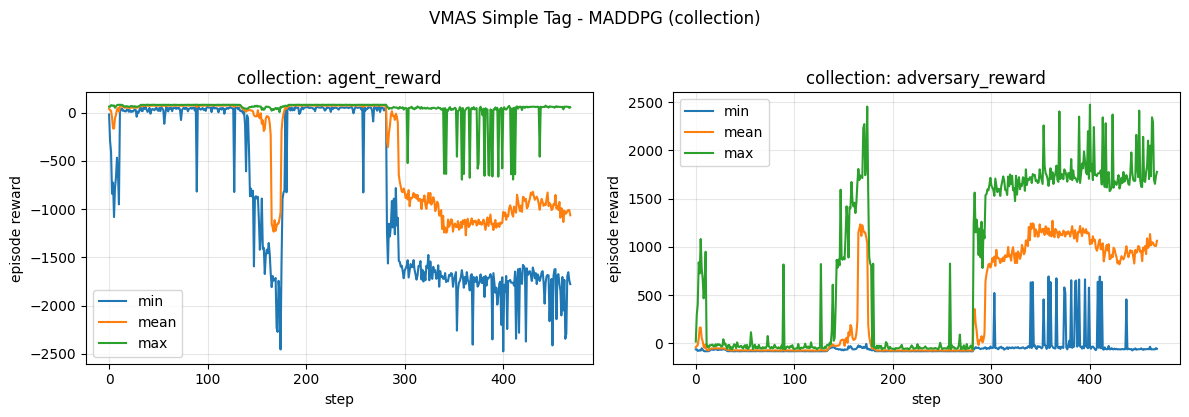

Saved figure to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/figures/maddpg_eval_reward_curves.png


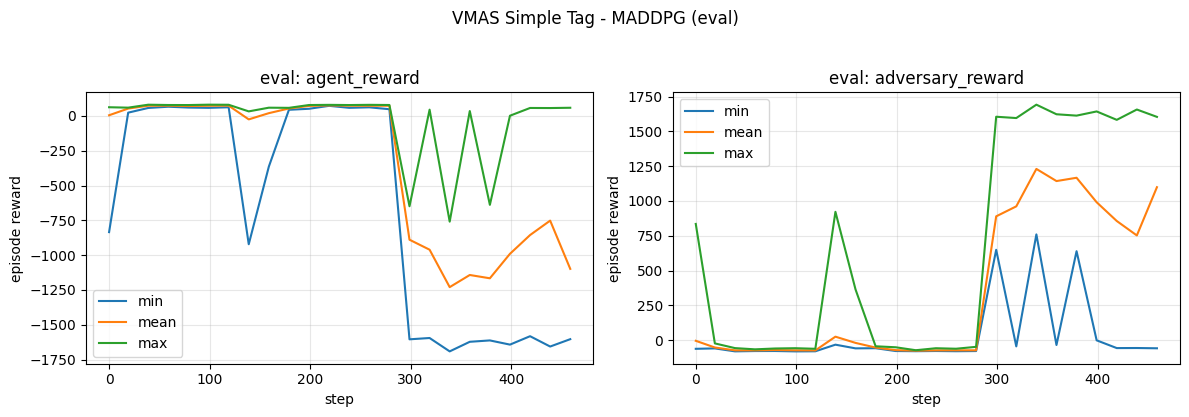

Saved MADDPG figures:
/home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/figures/maddpg_collection_reward_curves.png
/home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/figures/maddpg_eval_reward_curves.png


In [6]:
maddpg_figure_paths = plot_reward_metrics_for_run(MADDPG_RUN_ROOT, MADDPG_ALGORITHM)
print("Saved MADDPG figures:")
for figure_path in maddpg_figure_paths:
    print(figure_path)


### Evaluate latest MADDPG checkpoint


Evaluating checkpoint: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27/checkpoints/checkpoint_3001600.pt


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/benchmarl/experiment/experiment.py:313: UserWarning: max_n_frames and max_n_iters have both been set. The experiment will terminate after 469 iterations (3000000 frames).
  warnings.warn(



Reloaded experiment maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27 from /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27/checkpoints/checkpoint_3001600.pt.
Evaluation results logged to loggers=['csv'] and to a json file in the experiment folder.


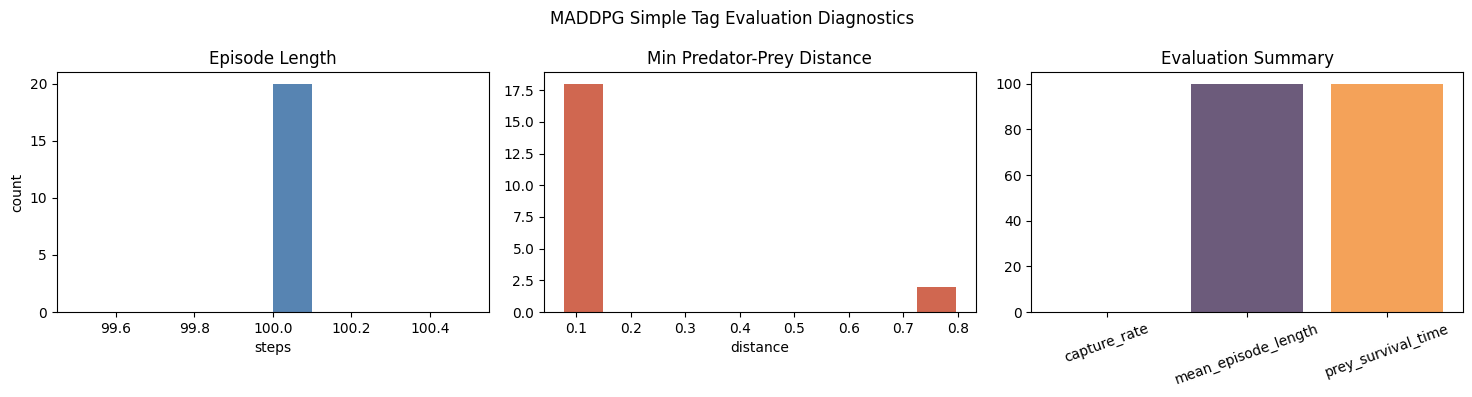

Saved diagnostics CSV to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/metrics/maddpg_eval_episode_metrics.csv
Saved diagnostics JSON to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/metrics/maddpg_eval_summary.json
Saved diagnostics figure to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/figures/maddpg_eval_diagnostics.png
MADDPG evaluation summary:
  capture_rate: 0.0000
  mean_episode_length: 100.0000
  mean_prey_survival_time: 100.0000
  mean_min_predator_prey_distance: 0.1557


In [7]:
latest_maddpg_ckpt = find_latest_checkpoint(MADDPG_RUN_ROOT)
if latest_maddpg_ckpt is None:
    print("No MADDPG checkpoint files found.")
else:
    print("Evaluating checkpoint:", latest_maddpg_ckpt)
    maddpg_eval_exp = Experiment.reload_from_file(
        str(latest_maddpg_ckpt),
        experiment_patch={
            "render": False,
            "evaluation": True,
            "evaluation_episodes": MADDPG_EVAL_EPISODES,
        },
    )
    maddpg_eval_exp.evaluate()

    maddpg_rollouts = collect_eval_rollouts(
        maddpg_eval_exp,
        episodes=MADDPG_EVAL_EPISODES,
        max_steps=MAX_STEPS,
    )
    maddpg_episode_df, maddpg_summary = summarize_simple_tag_rollouts(
        maddpg_rollouts,
        max_steps=MAX_STEPS,
    )
    save_simple_tag_eval_diagnostics(
        MADDPG_RUN_ROOT,
        MADDPG_ALGORITHM,
        maddpg_episode_df,
        maddpg_summary,
    )

    print("MADDPG evaluation summary:")
    for key, value in maddpg_summary.items():
        print(f"  {key}: {value:.4f}")


### Render trained MADDPG policy


In [8]:
render_latest_policy_video(MADDPG_RUN_ROOT, MADDPG_ALGORITHM, max_steps=MAX_STEPS)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/benchmarl/experiment/experiment.py:313: UserWarning: max_n_frames and max_n_iters have both been set. The experiment will terminate after 469 iterations (3000000 frames).
  warnings.warn(
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (3000000) is not exactly divisible by frames_per_batch (6400). This means 1600 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(



Reloaded experiment maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27 from /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/maddpg_simple_tag_mlp__f337f9b1_26_03_30-18_10_27/checkpoints/checkpoint_3001600.pt.
Captured 99 frames.
Saved video to: /home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/manual_videos/maddpg_eval.mp4


PosixPath('/home/wowthecoder/SRE-DQN/continous_action_space/benchmarl_runs/vmas_simple_tag_maddpg/manual_videos/maddpg_eval.mp4')